# Module 1: Options & Volatility Data Pipeline

This notebook acts as the foundational data ingestion layer for the options and volatility project. Its sole responsibility is to download, transform, and export a clean dataset that downstream models (Black-Scholes engine, ML volatility predictors, and backtester) will consume.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

UNDERLYING_TICKER = "^GSPC"  # S&P 500 Index (Price index)
OPTIONS_TICKER = "^SPX"      # S&P 500 Index Options

/Users/rooneysingh0027/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# 1. Fetch historical daily OHLCV for the underlying from 2015-01-01 to today
today_date = datetime.today()
print(f"Fetching historical data for {UNDERLYING_TICKER}...")
underlying_df = yf.download(UNDERLYING_TICKER, start="2015-01-01", end=today_date)

# Handle yfinance's MultiIndex column quirk (flatten columns if necessary)
if isinstance(underlying_df.columns, pd.MultiIndex):
    underlying_df.columns = underlying_df.columns.get_level_values(0)

# Reset index so 'Date' becomes a standard column
underlying_df = underlying_df.reset_index()

underlying_df.head()

Fetching historical data for ^GSPC...


[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2015-01-02,2058.199951,2072.360107,2046.040039,2058.899902,2708700000
1,2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000
2,2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000
3,2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000
4,2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000


In [3]:
# 2. Compute log returns and rolling historical volatility
underlying_df['log_return'] = np.log(underlying_df['Close'] / underlying_df['Close'].shift(1))

# Compute realized/historical volatility (HV) as rolling annualized standard deviation
# Annualization factor = sqrt(252 trading days)
annualization_factor = np.sqrt(252)

underlying_df['hv_10'] = underlying_df['log_return'].rolling(window=10).std() * annualization_factor
underlying_df['hv_21'] = underlying_df['log_return'].rolling(window=21).std() * annualization_factor
underlying_df['hv_63'] = underlying_df['log_return'].rolling(window=63).std() * annualization_factor

# Enforce the exact fixed contract for underlying data
underlying_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'log_return', 'hv_10', 'hv_21', 'hv_63']
underlying_df = underlying_df[underlying_cols]

underlying_df.tail()

Price,Date,Open,High,Low,Close,Volume,log_return,hv_10,hv_21,hv_63
2888,2026-06-30,7441.270020,7508.290039,7438.040039,7499.359863,6037540000,0.007889,0.141582,0.173588,0.145514
2889,2026-07-01,7478.839844,7521.810059,7449.629883,7483.229980,5782730000,-0.002153,0.139194,0.173290,0.135819
2890,2026-07-02,7495.140137,7540.750000,7427.549805,7483.240234,5463520000,0.000001,0.122598,0.173157,0.135506
2891,2026-07-06,7506.959961,7551.310059,7500.970215,7537.430176,4971110000,0.007215,0.115600,0.173538,0.135883
2892,2026-07-07,7516.629883,7536.060059,7478.629883,7503.850098,5049590000,-0.004465,0.116425,0.173479,0.136441


In [4]:
# 3. Fetch current live options chain for the nearest 3 expiries
ticker_obj = yf.Ticker(OPTIONS_TICKER)
available_expiries = ticker_obj.options

# Fallback logic if ^SPX options are temporarily empty or unavailable via yfinance
if not available_expiries:
    print(f"Warning: No options found for {OPTIONS_TICKER}. Trying fallback to {UNDERLYING_TICKER}...")
    ticker_obj = yf.Ticker(UNDERLYING_TICKER)
    available_expiries = ticker_obj.options

if not available_expiries:
    print(f"ERROR: No options found for fallback {UNDERLYING_TICKER} either.")
    print(f"Please manually verify at https://finance.yahoo.com/quote/%5ESPX/options/ whether Yahoo currently lists a chain.")
else:
    available_expiries = available_expiries[:3]

# CAVEAT: yfinance's daily Close for the current day may not be populated until
# after market close, so spot_price here could reflect the previous trading day's
# close while the live option chain reflects real-time market data. This means
# moneyness calculations have a potential same-day timing mismatch.
# This is acceptable for research purposes but should be mentioned in the written report.
spot_price = underlying_df['Close'].dropna().iloc[-1]

chain_frames = []
if available_expiries:
    for expiry in available_expiries:
        try:
            opt_chain = ticker_obj.option_chain(expiry)
            
            # Time to expiry calculation
            expiry_date = datetime.strptime(expiry, '%Y-%m-%d')
            time_to_expiry = (expiry_date - today_date).days / 365.0
            
            # Append 'call' type flag
            calls = opt_chain.calls.copy()
            calls['option_type'] = 'call'
            
            # Append 'put' type flag
            puts = opt_chain.puts.copy()
            puts['option_type'] = 'put'
            
            # Combine into a single chain dataframe for this expiry
            chain_df = pd.concat([calls, puts], ignore_index=True)
            if chain_df.empty:
                continue
                
            chain_df['expiry'] = expiry
            chain_df['time_to_expiry'] = time_to_expiry
            chain_df['moneyness'] = chain_df['strike'] / spot_price
            
            chain_frames.append(chain_df)
        except Exception as e:
            print(f"Failed to fetch options for expiry {expiry}: {e}")

if chain_frames:
    live_chain_df = pd.concat(chain_frames, ignore_index=True)

    # --- FIX 1: Filter illiquid/garbage IV data before enforcing columns ---
    n_total = len(live_chain_df)

    # Keep rows where volume > 0 OR openInterest > 0 (handles NaNs by treating them as 0)
    has_activity = (live_chain_df['volume'].fillna(0) > 0) | (live_chain_df['openInterest'].fillna(0) > 0)

    # Keep rows where impliedVolatility is strictly between 0 and 3.0
    valid_iv = (live_chain_df['impliedVolatility'].fillna(0) > 0) & (live_chain_df['impliedVolatility'].fillna(0) <= 3.0)

    live_chain_df = live_chain_df[has_activity & valid_iv].copy()
    n_dropped = n_total - len(live_chain_df)

    print(f"Filtered {n_dropped} illiquid/invalid IV rows out of {n_total}")
    # -----------------------------------------------------------------------

    # Enforce the exact fixed contract for options data
    chain_cols = ['strike', 'expiry', 'moneyness', 'time_to_expiry', 'bid', 'ask', 
                  'impliedVolatility', 'openInterest', 'volume', 'option_type']
    live_chain_df = live_chain_df[chain_cols]
else:
    print("No option chain data could be successfully fetched or constructed.")
    # Create empty dataframe with expected columns to prevent downstream crashing
    chain_cols = ['strike', 'expiry', 'moneyness', 'time_to_expiry', 'bid', 'ask', 
                  'impliedVolatility', 'openInterest', 'volume', 'option_type']
    live_chain_df = pd.DataFrame(columns=chain_cols)

live_chain_df.head()

Filtered 17 illiquid/invalid IV rows out of 1232


,strike,expiry,moneyness,time_to_expiry,bid,ask,impliedVolatility,openInterest,volume,option_type
0,4600.0,2026-07-08,0.613019,-0.00274,2850.5,2871.3,0.000010,4.0,NaN,call
1,4800.0,2026-07-08,0.639672,-0.00274,2650.5,2671.3,0.000010,2.0,1.0,call
2,5200.0,2026-07-08,0.692978,-0.00274,2250.5,2271.3,0.000010,5.0,NaN,call
3,5400.0,2026-07-08,0.719631,-0.00274,2081.0,2105.0,2.411137,0.0,1.0,call
4,5600.0,2026-07-08,0.746284,-0.00274,1850.5,1870.8,0.000010,2.0,NaN,call


### Design Choices: Index Options vs. ETF Options (European vs. American)

**Why `^SPX` (S&P 500 Index) instead of `SPY` (ETF):**  
The Black-Scholes pricing engine developed in Module 2 strictly assumes European-style options (which can only be exercised at expiration). `SPY` options are American-style and carry an early-exercise premium, creating a structural pricing mismatch. `^SPX` options are European-style and cash-settled, perfectly aligning with our Black-Scholes model's mathematical assumptions.

**Why `yfinance` only provides live chains:**  
Free public APIs like `yfinance` exclusively stream the *current*, live snapshot of the options market. True historical options data (end-of-day options chains, historical bid/ask spreads, and archival implied volatility surfaces) are massive datasets. Because of their commercial value and size, they are practically never available for free.

**How this project handles historical option behavior:**  
Because we lack actual historical options chains, this project relies on synthetic reconstruction. In subsequent modules, we utilize the **Black-Scholes engine** driven by the rolling realized historical volatility metrics (`hv_21` and `hv_63`) computed in this notebook. Rather than querying real historical bid/asks, our backtester will mathematically price options back in time based on the true underlying asset path and measured historical variance. This allows us to perform meaningful, robust ML and backtesting workflows entirely off freely available data.

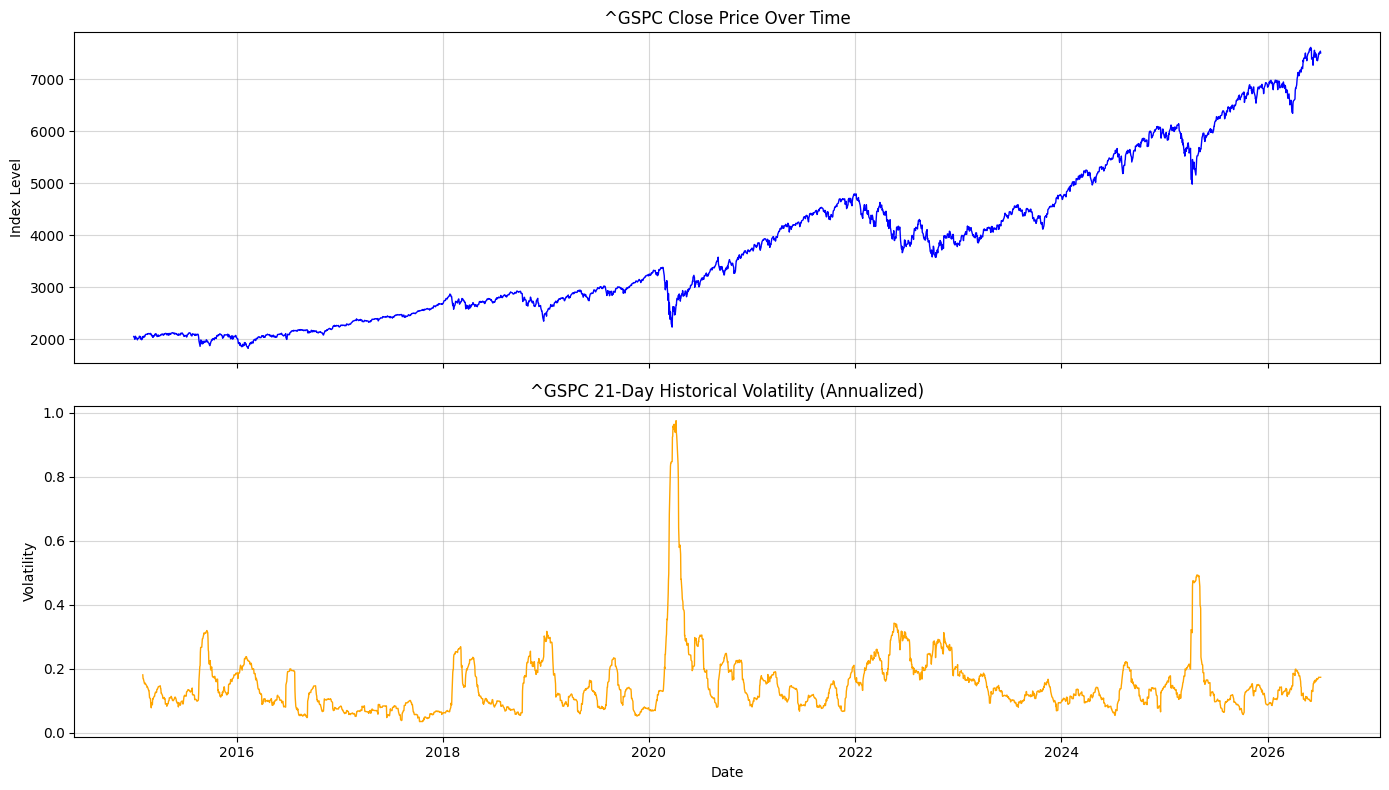

In [5]:
# 4. Exploratory Data Analysis (EDA): Underlying Price & Historical Volatility
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot Close price
ax1.plot(underlying_df['Date'], underlying_df['Close'], color='blue', linewidth=1)
ax1.set_title(f'{UNDERLYING_TICKER} Close Price Over Time')
ax1.set_ylabel('Index Level')
ax1.grid(True, alpha=0.5)

# Plot 21-Day Historical Volatility
ax2.plot(underlying_df['Date'], underlying_df['hv_21'], color='orange', linewidth=1)
ax2.set_title(f'{UNDERLYING_TICKER} 21-Day Historical Volatility (Annualized)')
ax2.set_ylabel('Volatility')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

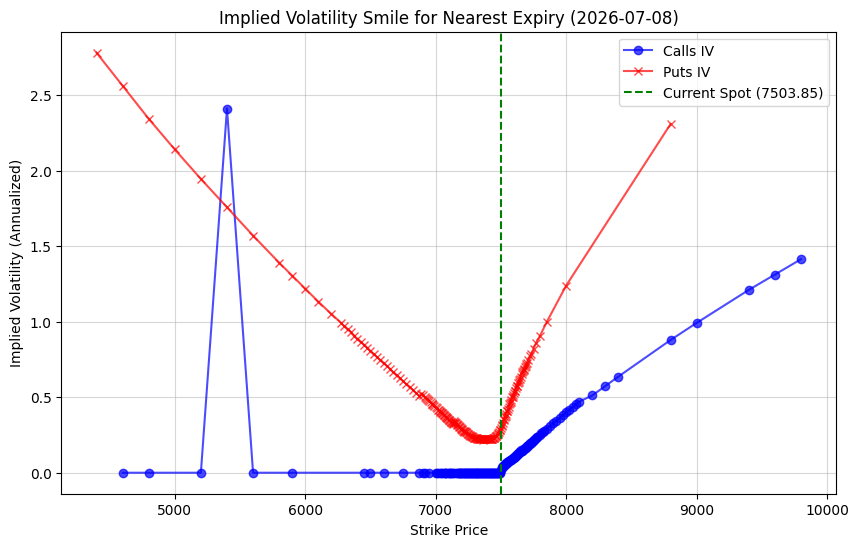

In [6]:
# 5. Exploratory Data Analysis (EDA): Implied Volatility Smile
if not live_chain_df.empty:
    # Extract data for the nearest expiry
    nearest_expiry = available_expiries[0]
    smile_df = live_chain_df[live_chain_df['expiry'] == nearest_expiry]
    
    calls = smile_df[smile_df['option_type'] == 'call']
    puts = smile_df[smile_df['option_type'] == 'put']
    
    plt.figure(figsize=(10, 6))
    plt.plot(calls['strike'], calls['impliedVolatility'], 'bo-', label='Calls IV', alpha=0.7)
    plt.plot(puts['strike'], puts['impliedVolatility'], 'rx-', label='Puts IV', alpha=0.7)
    
    # Mark current spot price
    plt.axvline(x=spot_price, color='green', linestyle='--', label=f'Current Spot ({spot_price:.2f})')
    
    plt.title(f'Implied Volatility Smile for Nearest Expiry ({nearest_expiry})')
    plt.xlabel('Strike Price')
    plt.ylabel('Implied Volatility (Annualized)')
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()
else:
    print("Live options chain is empty. Skipping IV smile plot.")

In [7]:
# 6. Export exact contract formats for downstream modules
os.makedirs('data', exist_ok=True)

underlying_df.to_csv('data/underlying_history.csv', index=False)
live_chain_df.to_csv('data/live_chain_snapshot.csv', index=False)

print("Data pipeline successfully executed. Fixed-contract files saved:")
print(" -> data/underlying_history.csv")
print(" -> data/live_chain_snapshot.csv")

Data pipeline successfully executed. Fixed-contract files saved:
 -> data/underlying_history.csv
 -> data/live_chain_snapshot.csv
